In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files

# Upload the dataset file
uploaded = files.upload()

Saving sample.csv to sample (1).csv


In [ ]:
# Load the CSV into a DataFrame
# parse_dates tells pandas to treat the 'date' column as real dates
df = pd.read_csv("sample.csv", parse_dates=["Order Date"], encoding='latin1')
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(df.head())         # first 5 rows
print(df.shape)          # (rows, columns)
print(df.info())         # column names + data types + null count
print(df.describe())     # statistics: mean, min, max, std

# Check for missing values
print(df.isnull().sum())
# Output example:


   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("sample.csv", encoding="latin-1")
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print("Missing before:", df["Sales"].isnull().sum())

# Method 1: Drop rows with missing values
df_drop = df.dropna()
print("Rows after dropna:", len(df_drop))   # you lose rows

# Method 2: Fill with column mean
df_mean = df.copy()
df_mean["Sales"] = df_mean["Sales"].fillna(df_mean["Sales"].mean())
print("Mean fill done. Missing:", df_mean["Sales"].isnull().sum())

# Method 3: Linear interpolation (BEST for time series)
df_interp = df.copy()
df_interp["Sales"] = df_interp["Sales"].interpolate(method="linear")
print("Interpolation done. Missing:", df_interp["Sales"].isnull().sum())

# See the difference at one missing spot
# Find first missing index
if df["Sales"].isnull().any():
    missing_idx = df[df["Sales"].isnull()].index[0]
    print("\nAt the first missing row:")
    print("  Original  :", df.loc[missing_idx, "Sales"])         # NaN
    print("  Mean fill :", df_mean.loc[missing_idx, "Sales"])    # flat average
    print("  Interpolated:", df_interp.loc[missing_idx, "Sales"])# value that fits the trend
else:
    print("\nNo missing values found in the 'Sales' column to demonstrate interpolation differences.")

Missing before: 0
Rows after dropna: 9994
Mean fill done. Missing: 0
Interpolation done. Missing: 0

No missing values found in the 'Sales' column to demonstrate interpolation differences.


In [ ]:
df = pd.read_csv("sample.csv", encoding="latin-1", parse_dates=["Order Date"])
df["Sales"] = df["Sales"].interpolate(method="linear")

# --- DATE FEATURES --- (extract numbers from the date)
df["month"]        = df["Order Date"].dt.month         # 1–12
df["day_of_week"]  = df["Order Date"].dt.dayofweek     # 0=Monday, 6=Sunday
df["day_of_year"]  = df["Order Date"].dt.dayofyear     # 1–365
df["quarter"]      = df["Order Date"].dt.quarter       # 1–4
df["week_of_year"] = df["Order Date"].dt.isocalendar().week.astype(int)
df["is_weekend"]   = (df["day_of_week"] >= 5).astype(int)  # 1 if Sat/Sun

# --- LAG FEATURES --- (past sales as predictors)
df["lag_1"]  = df["Sales"].shift(1)   # yesterday's sales
df["lag_7"]  = df["Sales"].shift(7)   # same day last week
df["lag_30"] = df["Sales"].shift(30)  # same day last month

# --- ROLLING AVERAGE FEATURES --- (trend smoothing)
df["rolling_7d"]  = df["Sales"].rolling(window=7).mean()
df["rolling_30d"] = df["Sales"].rolling(window=30).mean()

# Drop rows where lag/rolling creates NaN (first 30 rows)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(df[["Order Date","Sales","month","day_of_week","lag_1","rolling_7d"]].head(10))
print("\nFinal shape:", df.shape)

  Order Date      Sales  month  day_of_week      lag_1  rolling_7d
0 2015-09-17     3.2640      9            3   124.2000  623.908571
1 2015-09-17    86.3040      9            3     3.2640  487.004857
2 2015-09-17     6.8580      9            3    86.3040  486.320571
3 2015-09-17    15.7600      9            3     6.8580  475.633429
4 2017-10-19    29.4720     10            3    15.7600   39.353714
5 2016-12-08  1097.5440     12            3    29.4720  194.771714
6 2016-12-08   190.9200     12            3  1097.5440  204.303143
7 2015-12-27   113.3280     12            6   190.9200  220.026571
8 2015-12-27   532.3992     12            6   113.3280  283.754457
9 2015-12-27   212.0580     12            6   532.3992  313.068743

Final shape: (9964, 32)


In [ ]:
 #Step 1: Define which columns are features (X) and target (y)
FEATURES = ["day_of_week","month","quarter","day_of_year",
            "is_weekend","lag_1","lag_7","lag_30",
            "rolling_7d","rolling_30d"]
X = df[FEATURES]
y = df["Sales"]

# Step 2: Split by date — last 60 days = test
split_date = df["Order Date"].max() - pd.Timedelta(days=60)
X_train = X[df["Order Date"] <= split_date]
X_test  = X[df["Order Date"] >  split_date]
y_train = y[df["Order Date"] <= split_date]
y_test  = y[df["Order Date"] >  split_date]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

# Step 3: Scale features
scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # learn scale from train only!
X_test_s  = scaler.transform(X_test)       # apply same scale to test

# Step 4: Create and train the model
model = LinearRegression()
model.fit(X_train_s, y_train)   #training

# Step 5: Predict and evaluate
preds = model.predict(X_test_s)

mae = mean_absolute_error(y_test, preds)
r2  = r2_score(y_test, preds)

print(f"MAE  = {mae:.2f}  (average error per day in sales units)")
print(f"R²   = {r2:.4f}  (1.0 = perfect prediction)")

Train size: 9043, Test size: 921
MAE  = 250.54  (average error per day in sales units)
R²   = 0.0918  (1.0 = perfect prediction)


Weekly shape: (209, 3)
                    week     sales       date
0  2013-12-30/2014-01-05   324.044 2013-12-30
1  2014-01-06/2014-01-12  4599.572 2014-01-06
2  2014-01-13/2014-01-19  4509.127 2014-01-13
3  2014-01-20/2014-01-26  3842.388 2014-01-20
4  2014-01-27/2014-02-02  1642.310 2014-01-27
After features: (157, 12)

Train: 145, Test: 12

Linear Regression:
  MAE = 6566.07  (avg error per week in $)
  R²  = 0.2833

Random Forest:
  MAE = 6119.87  (avg error per week in $)
  R²  = 0.3006

Gradient Boosting:
  MAE = 6235.02  (avg error per week in $)
  R²  = 0.3545


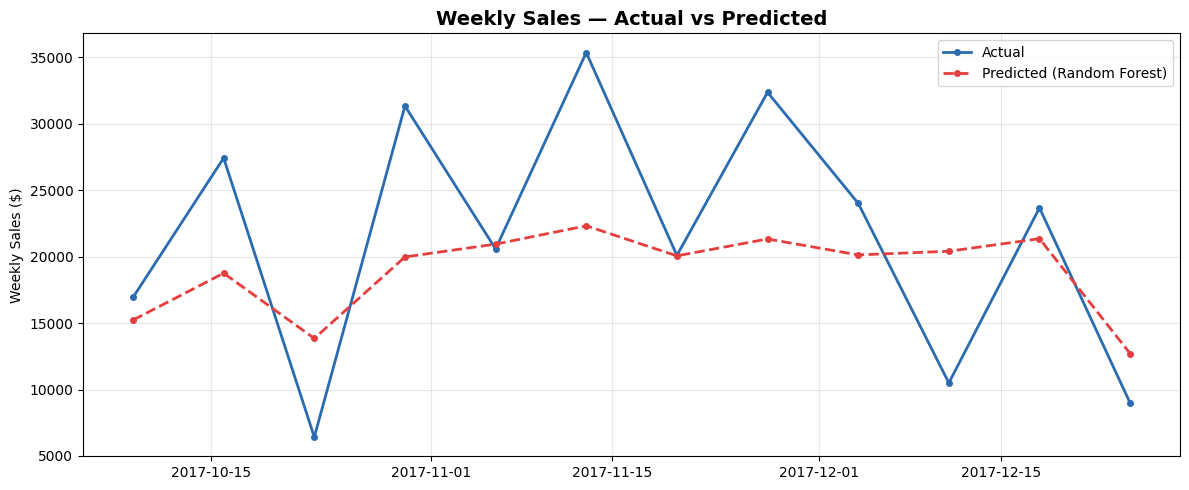


Best model: Random Forest  |  MAE = $6,119.87 per week


In [ ]:
#as R-square is 0.09 , it has to be greater than 0.1, here it is too small

df = pd.read_csv("sample.csv", encoding="latin-1")
df["Order Date"] = pd.to_datetime(df["Order Date"])

# --- FIX 1: Aggregate by WEEK instead of day ---
# Weekly totals smooth out random single-order spikes
df["week"] = df["Order Date"].dt.to_period("W")
weekly_df = df.groupby("week")["Sales"].sum().reset_index()
weekly_df.columns = ["week", "sales"]
weekly_df["date"] = weekly_df["week"].dt.start_time
weekly_df = weekly_df.sort_values("date").reset_index(drop=True)

print("Weekly shape:", weekly_df.shape)  # ~209 weeks
print(weekly_df.head())

# --- Feature engineering on weekly data ---
weekly_df["month"]       = weekly_df["date"].dt.month
weekly_df["quarter"]     = weekly_df["date"].dt.quarter
weekly_df["week_of_year"]= weekly_df["date"].dt.isocalendar().week.astype(int)

# Lag = previous weeks (not days)
weekly_df["lag_1"]  = weekly_df["sales"].shift(1)   # last week
weekly_df["lag_4"]  = weekly_df["sales"].shift(4)   # 4 weeks ago
weekly_df["lag_52"] = weekly_df["sales"].shift(52)  # same week last year

weekly_df["rolling_4w"]  = weekly_df["sales"].rolling(4).mean()   # 1-month avg
weekly_df["rolling_12w"] = weekly_df["sales"].rolling(12).mean()  # 3-month avg

# FIX 2: Add a year trend column (captures overall growth)
weekly_df["week_number"] = np.arange(len(weekly_df))

weekly_df.dropna(inplace=True)
weekly_df.reset_index(drop=True, inplace=True)
print("After features:", weekly_df.shape)

# --- Train/test split: last 12 weeks = test ---
FEATURES = ["month","quarter","week_of_year",
            "lag_1","lag_4","lag_52",
            "rolling_4w","rolling_12w","week_number"]

X = weekly_df[FEATURES]
y = weekly_df["sales"]

# Use last 12 weeks as test (about 3 months)
X_train, X_test = X.iloc[:-12], X.iloc[-12:]
y_train, y_test = y.iloc[:-12], y.iloc[-12:]
dates_test = weekly_df["date"].iloc[-12:]

print(f"\nTrain: {len(X_train)}, Test: {len(X_test)}")

# --- Scale + Train ---
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

models = {
    "Linear Regression" : LinearRegression(),
    "Random Forest"     : RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=200, random_state=42),
}

best_mae   = float("inf")
best_preds = None
best_name  = ""

for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    mae = mean_absolute_error(y_test, preds)
    r2  = r2_score(y_test, preds)
    print(f"\n{name}:")
    print(f"  MAE = {mae:.2f}  (avg error per week in $)")
    print(f"  R²  = {r2:.4f}")
    if mae < best_mae:
        best_mae   = mae
        best_preds = preds
        best_name  = name

# --- Visualise actual vs predicted ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates_test.values, y_test.values,
        label="Actual", color="#2B6CB0", linewidth=2, marker="o", markersize=4)
ax.plot(dates_test.values, best_preds,
        label=f"Predicted ({best_name})", color="#E53E3E",
        linewidth=2, linestyle="--", marker="o", markersize=4)
ax.set_title("Weekly Sales — Actual vs Predicted", fontsize=14, fontweight="bold")
ax.set_ylabel("Weekly Sales ($)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("weekly_actual_vs_pred.png", dpi=150)
plt.show()

print(f"\nBest model: {best_name}  |  MAE = ${best_mae:,.2f} per week")

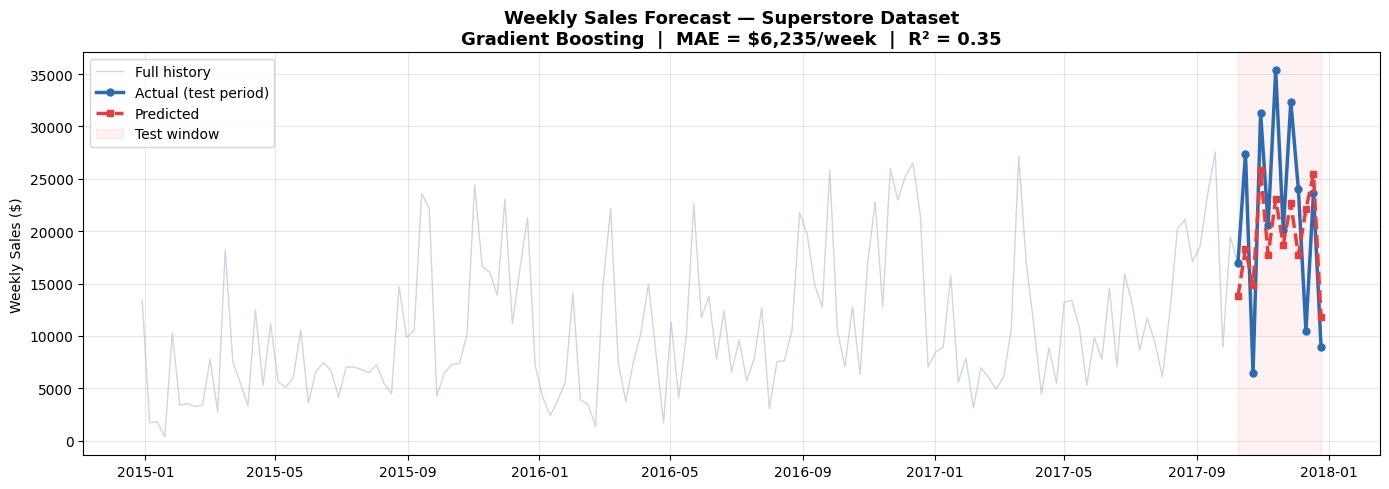

Chart 1 saved


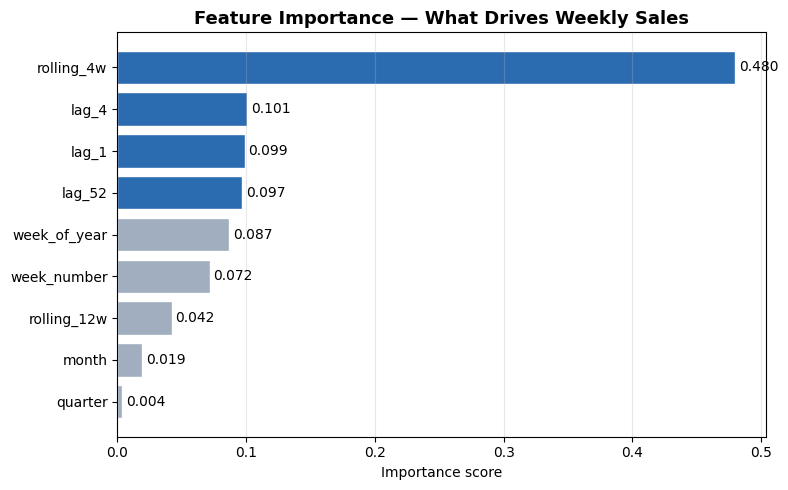

Chart 2 saved


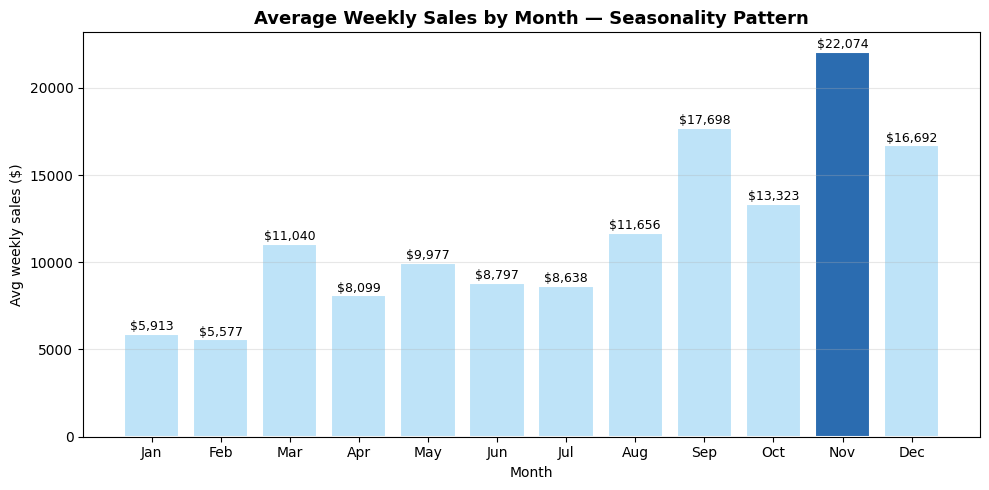

Chart 3 saved

  BUSINESS FORECAST SUMMARY
  Model          : Gradient Boosting
  Forecast period: Last 12 weeks of data
  Avg error/week : $6,235
  R² score       : 0.35
  Avg weekly sales (predicted) : $19,325
  Peak sales month             : Nov

  Business Insights:
  - Stock up inventory before Nov (peak season)
  - Budget for ~$19,325 in weekly revenue
  - Forecast error margin is ±$6,235 per week


In [ ]:
#representin the overall output by matplotlib

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# --- Rebuild weekly data (same as before) ---
df = pd.read_csv("sample.csv", encoding="latin-1")
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["week"] = df["Order Date"].dt.to_period("W")
weekly_df  = df.groupby("week")["Sales"].sum().reset_index()
weekly_df.columns = ["week", "sales"]
weekly_df["date"] = weekly_df["week"].dt.start_time
weekly_df = weekly_df.sort_values("date").reset_index(drop=True)

weekly_df["month"]        = weekly_df["date"].dt.month
weekly_df["quarter"]      = weekly_df["date"].dt.quarter
weekly_df["week_of_year"] = weekly_df["date"].dt.isocalendar().week.astype(int)
weekly_df["lag_1"]        = weekly_df["sales"].shift(1)
weekly_df["lag_4"]        = weekly_df["sales"].shift(4)
weekly_df["lag_52"]       = weekly_df["sales"].shift(52)
weekly_df["rolling_4w"]   = weekly_df["sales"].rolling(4).mean()
weekly_df["rolling_12w"]  = weekly_df["sales"].rolling(12).mean()
weekly_df["week_number"]  = np.arange(len(weekly_df))
weekly_df.dropna(inplace=True)
weekly_df.reset_index(drop=True, inplace=True)

FEATURES = ["month","quarter","week_of_year",
            "lag_1","lag_4","lag_52",
            "rolling_4w","rolling_12w","week_number"]

X = weekly_df[FEATURES]
y = weekly_df["sales"]

X_train, X_test = X.iloc[:-12], X.iloc[-12:]
y_train, y_test = y.iloc[:-12], y.iloc[-12:]
dates_test = weekly_df["date"].iloc[-12:]

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = GradientBoostingRegressor(n_estimators=200, random_state=42)
model.fit(X_train_s, y_train)
preds = model.predict(X_test_s)

mae = mean_absolute_error(y_test, preds)
r2  = r2_score(y_test, preds)

# ═══════════════════════════════════════════════
# CHART 1: Full history + actual vs predicted
# ═══════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))

# Full history in light color for context
ax.plot(weekly_df["date"], weekly_df["sales"],
        color="#A0AEC0", linewidth=1, alpha=0.5, label="Full history")

# Actual test period
ax.plot(dates_test.values, y_test.values,
        color="#2B6CB0", linewidth=2.5, marker="o",
        markersize=5, label="Actual (test period)")

# Predicted
ax.plot(dates_test.values, preds,
        color="#E53E3E", linewidth=2.5, linestyle="--",
        marker="s", markersize=5, label="Predicted")

# Shade the test region
ax.axvspan(dates_test.values[0], dates_test.values[-1],
           alpha=0.07, color="#E53E3E", label="Test window")

ax.set_title("Weekly Sales Forecast — Superstore Dataset\n"
             f"Gradient Boosting  |  MAE = ${mae:,.0f}/week  |  R² = {r2:.2f}",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Weekly Sales ($)")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("chart1_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 saved")

# ═══════════════════════════════════════════════
# CHART 2: Feature importance (what drives sales)
# ═══════════════════════════════════════════════
importances = pd.Series(model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)  # ascending for horizontal bar

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2B6CB0" if v > importances.median() else "#A0AEC0"
          for v in importances.values]
bars = ax.barh(importances.index, importances.values,
               color=colors, edgecolor="white")

# Value labels on bars
for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=10)

ax.set_title("Feature Importance — What Drives Weekly Sales",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance score")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("chart2_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved")

# ═══════════════════════════════════════════════
# CHART 3: Seasonal pattern (monthly averages)
# ═══════════════════════════════════════════════
monthly_avg = weekly_df.groupby("month")["sales"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
peak_month  = monthly_avg.idxmax()

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#2B6CB0" if m == peak_month else "#BEE3F8"
              for m in monthly_avg.index]
bars = ax.bar(month_names, monthly_avg.values,
              color=bar_colors, edgecolor="white", linewidth=1.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f"${bar.get_height():,.0f}",
            ha="center", va="bottom", fontsize=9)

ax.set_title("Average Weekly Sales by Month — Seasonality Pattern",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Avg weekly sales ($)")
ax.set_xlabel("Month")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("chart3_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 3 saved")

# ═══════════════════════════════════════════════
# BUSINESS SUMMARY (print to terminal)
# ═══════════════════════════════════════════════
total_predicted  = preds.sum()
avg_weekly_pred  = preds.mean()
peak_season_month = month_names[peak_month - 1]

print("\n" + "="*52)
print("  BUSINESS FORECAST SUMMARY")
print("="*52)
print(f"  Model          : Gradient Boosting")
print(f"  Forecast period: Last 12 weeks of data")
print(f"  Avg error/week : ${mae:,.0f}")
print(f"  R² score       : {r2:.2f}")
print(f"  Avg weekly sales (predicted) : ${avg_weekly_pred:,.0f}")
print(f"  Peak sales month             : {peak_season_month}")
print("="*52)
print("\n  Business Insights:")
print(f"  - Stock up inventory before {peak_season_month} (peak season)")
print(f"  - Budget for ~${avg_weekly_pred:,.0f} in weekly revenue")
print(f"  - Forecast error margin is ±${mae:,.0f} per week")
print("="*52)